In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import os
import sys
from pathlib import Path

# Проверяем, запускался ли уже этот блок
if "IS_ROOT_SET" not in globals():
    project_root = Path.cwd().parent.parent
    os.chdir(project_root)

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    # Создаем флаг-индикатор
    IS_ROOT_SET = True
    print("Корневая директория инициализирована.")
else:
    print("Инициализация уже была выполнена ранее.")

Инициализация уже была выполнена ранее.


In [8]:
from mmdet.apis import init_detector, inference_detector
from mmdet.registry import VISUALIZERS
import mmcv

На данный момент невозможно скачать веса модели с сайта openmmlab, так как он лежит

In [9]:
config_file = "src/mmdetection/configs/fcos_minecraft.py"
checkpoint_file = (
    "src/artifacts/checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth"
)

In [10]:
model = init_detector(config_file, checkpoint=checkpoint_file, device="cuda:0")

/home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/__init__.py:169: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  _bootstrap._exec(spec, module)


Loads checkpoint by local backend from path: src/artifacts/checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([17, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([17]).


In [11]:
input_image = (
    "datasets/minecraft/test/image11_png_jpg.rf.64ae384b4756d555a3753877a81e1b04.jpg"
)
output_dir = "src/artifacts/inference"
os.makedirs(output_dir, exist_ok=True)

In [12]:
result = inference_detector(model, input_image)

/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [13]:
import matplotlib.pyplot as plt

/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


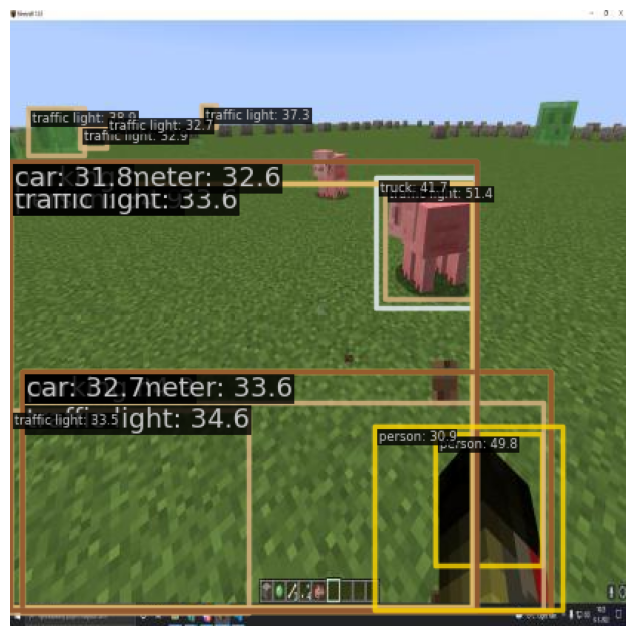

✅ Результат успешно сохранен в: src/artifacts/inference/test_pretrained.jpg


In [14]:
img = mmcv.imread(input_image)
img = mmcv.imconvert(img, "bgr", "rgb")

visualizer = VISUALIZERS.build(model.cfg.visualizer)
visualizer.dataset_meta = model.dataset_meta

visualizer.add_datasample(
    name="result",
    image=img,
    data_sample=result,
    draw_gt=False,
    pred_score_thr=0.3,
    show=False,
)

result_img = visualizer.get_image()

plt.figure(figsize=(12, 8))
plt.imshow(result_img)
plt.axis("off")
plt.show()

output_file = os.path.join(output_dir, "test_pretrained.jpg")
mmcv.imwrite(mmcv.imconvert(result_img, "rgb", "bgr"), output_file)
print(f"✅ Результат успешно сохранен в: {output_file}")

In [17]:
from mmengine.config import Config
from mmengine.runner import Runner

cfg = Config.fromfile(config_file)

cfg.work_dir = 'src/artifacts/checkpoints/fcos_minecraft_50e'
cfg.load_from = None
cfg.resume = True

runner = Runner.from_cfg(cfg)

runner.train()


06/12 12:34:32 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.15 (main, Jun 11 2026, 04:03:40) [Clang 22.1.3 ]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 2017190028
    GPU 0: Tesla T4
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 12.2, V12.2.140
    GCC: cc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
    PyTorch: 2.1.2+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gencode;arch=comp

/home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/__init__.py:169: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  _bootstrap._exec(spec, module)


06/12 12:34:33 - mmengine - INFO - Config:
MINECRAFT_CLASS_COLORS_RGB = dict(
    bee=(
        255,
        215,
        0,
    ),
    chicken=(
        255,
        165,
        0,
    ),
    cow=(
        139,
        69,
        19,
    ),
    creeper=(
        0,
        255,
        0,
    ),
    enderman=(
        148,
        0,
        211,
    ),
    fox=(
        255,
        69,
        0,
    ),
    frog=(
        85,
        107,
        47,
    ),
    ghast=(
        240,
        248,
        255,
    ),
    goat=(
        245,
        245,
        220,
    ),
    llama=(
        222,
        184,
        135,
    ),
    pig=(
        255,
        182,
        193,
    ),
    sheep=(
        255,
        255,
        255,
    ),
    skeleton=(
        192,
        192,
        192,
    ),
    spider=(
        45,
        45,
        45,
    ),
    turtle=(
        34,
        139,
        34,
    ),
    wolf=(
        176,
        196,
        222,
    ),
    zombie=(
  

/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


06/12 12:34:34 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
06/12 12:34:34 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

FCOS(
  (data_preprocessor): DetDataPreprocessor()
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): ResLayer(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
   

In [18]:
from mmdet.apis import DetInferencer

inferencer = DetInferencer(
    model="src/artifacts/checkpoints/fcos_minecraft_50e/fcos_minecraft.py",
    weights="src/artifacts/checkpoints/fcos_minecraft_50e/best_coco_bbox_mAP_epoch_33.pth",
    device="cuda:0",
)

Loads checkpoint by local backend from path: src/artifacts/checkpoints/fcos_minecraft_50e/best_coco_bbox_mAP_epoch_33.pth
06/12 14:47:20 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.


/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


In [ ]:
inferencer(
    "datasets/minecraft/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg",
    out_dir="src/artifacts/fcos_minecraft_50e/predictions",
    no_save_pred=False,
    pred_score_thr=0.3,
)

/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

{'predictions': [{'labels': [11,
    1,
    10,
    9,
    8,
    5,
    2,
    11,
    15,
    12,
    6,
    2,
    10,
    8,
    7,
    16,
    11,
    10,
    10,
    10,
    2],
   'scores': [0.5290331840515137,
    0.2203051596879959,
    0.15208226442337036,
    0.13344627618789673,
    0.1321064978837967,
    0.11056376993656158,
    0.06642599403858185,
    0.05827668309211731,
    0.056529413908720016,
    0.03610406816005707,
    0.03583553060889244,
    0.02814572863280773,
    0.025246169418096542,
    0.014697638340294361,
    0.011946653947234154,
    0.011237312108278275,
    0.008864641189575195,
    0.00450875423848629,
    0.00444499496370554,
    0.00404817471280694,
    0.002756685484200716],
   'bboxes': [[123.80547332763672,
     61.53104019165039,
     211.67645263671875,
     193.93670654296875],
    [123.80547332763672,
     61.53104019165039,
     211.67645263671875,
     193.93670654296875],
    [124.6630630493164,
     60.01592254638672,
     213.167083740

In [20]:
cfg = Config.fromfile(config_file)

cfg.work_dir = 'src/artifacts/fcos_minecraft_50e'

cfg.load_from = 'src/artifacts/checkpoints/fcos_minecraft_50e/best_coco_bbox_mAP_epoch_33.pth' 
cfg.resume = False 

runner = Runner.from_cfg(cfg)
runner.test()

06/12 14:48:44 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.15 (main, Jun 11 2026, 04:03:40) [Clang 22.1.3 ]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 814530067
    GPU 0: Tesla T4
    CUDA_HOME: /usr
    NVCC: Cuda compilation tools, release 12.2, V12.2.140
    GCC: cc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
    PyTorch: 2.1.2+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.1.1 (Git Hash 64f6bcbcbab628e96f33a62c3e975f8535a7bde4)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gencode;arch=compu

/home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/__init__.py:169: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  _bootstrap._exec(spec, module)


06/12 14:48:45 - mmengine - INFO - Config:
MINECRAFT_CLASS_COLORS_RGB = dict(
    bee=(
        255,
        215,
        0,
    ),
    chicken=(
        255,
        165,
        0,
    ),
    cow=(
        139,
        69,
        19,
    ),
    creeper=(
        0,
        255,
        0,
    ),
    enderman=(
        148,
        0,
        211,
    ),
    fox=(
        255,
        69,
        0,
    ),
    frog=(
        85,
        107,
        47,
    ),
    ghast=(
        240,
        248,
        255,
    ),
    goat=(
        245,
        245,
        220,
    ),
    llama=(
        222,
        184,
        135,
    ),
    pig=(
        255,
        182,
        193,
    ),
    sheep=(
        255,
        255,
        255,
    ),
    skeleton=(
        192,
        192,
        192,
    ),
    spider=(
        45,
        45,
        45,
    ),
    turtle=(
        34,
        139,
        34,
    ),
    wolf=(
        176,
        196,
        222,
    ),
    zombie=(
  

/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


06/12 14:48:45 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
06/12 14:48:45 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:760: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(
/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:831: UserWarning: Warning: The polygon is out of bounds, the drawn polygon may not be in the image
  warnings.warn(
/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:508: UserWarning: Warning: The text is out of bounds, the drawn text may not be in the image
  warnings.warn(


06/12 14:49:45 - mmengine - INFO - Evaluating bbox...
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.41s).
Accumulating evaluation results...
DONE (t=0.17s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.284
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=1000 ] = 0.655
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=1000 ] = 0.231
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=1000 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=1000 ] = 0.288
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=1000 ] = 0.435
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.389
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=300 ] = 0.389
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=1000 ] = 0.389
 Average

{'coco/bbox_mAP': 0.284,
 'coco/bbox_mAP_50': 0.655,
 'coco/bbox_mAP_75': 0.231,
 'coco/bbox_mAP_s': 0.103,
 'coco/bbox_mAP_m': 0.288,
 'coco/bbox_mAP_l': 0.435}

In [22]:
import os
from mmdet.apis import DetInferencer

test_images_dir = 'datasets/minecraft/test'
output_dir = 'artifacts/inference/fcos'

os.makedirs(output_dir, exist_ok=True)

print("Запуск инференса FCOS на тестовой выборке...")


fcos_inferencer = DetInferencer(
    model='src/artifacts/fcos_minecraft_50e/fcos_minecraft.py', 
    weights='src/artifacts/checkpoints/fcos_minecraft_50e/best_coco_bbox_mAP_epoch_33.pth',
    device='cuda:0'
)


fcos_inferencer(
    inputs=test_images_dir,
    out_dir='artifacts/inference/fcos_temp', 
    no_save_vis=False,
    batch_size=4,
    pred_score_thr=0.3
)


temp_vis_dir = 'artifacts/inference/fcos_temp/vis'

if os.path.exists(temp_vis_dir):
    for img_name in os.listdir(temp_vis_dir):
        old_path = os.path.join(temp_vis_dir, img_name)
        new_path = os.path.join(output_dir, img_name)
        os.rename(old_path, new_path)
    
    os.system('rm -rf artifacts/inference/fcos_temp')
    print(f"Все обработанные изображения успешно сохранены в: {output_dir}")
else:
    print("Ошибка: Визуализации не найдены. Проверьте логи инференсера.")


Запуск инференса FCOS на тестовой выборке...
Loads checkpoint by local backend from path: src/artifacts/checkpoints/fcos_minecraft_50e/best_coco_bbox_mAP_epoch_33.pth
06/12 14:53:14 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.


/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:760
: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(

/home/ubuntu/minecraft-object-detection/.venv/lib/python3.11/site-packages/mmengine/visualization/visualizer.py:831
: UserWarning: Warning: The polygon is out of bounds, the drawn polygon may not be in the image
  warnings.warn(

Все обработанные изображения успешно сохранены в: artifacts/inference/fcos


In [23]:

input_video = 'datasets/minecraft/video.mp4'
os.makedirs('artifacts/videos', exist_ok=True)


In [ ]:
import os
import cv2
import mmcv
from mmdet.apis import init_detector, inference_detector

# -------------------
# CONFIG
# -------------------
config_file = "src/artifacts/fcos_minecraft_50e/fcos_minecraft.py"
checkpoint_file = "src/artifacts/checkpoints/fcos_minecraft_50e/best_coco_bbox_mAP_epoch_33.pth"

input_video = "datasets/minecraft/video.mp4"

frames_dir = "artifacts/tmp_frames"
vis_dir = "artifacts/tmp_vis"
output_video = "artifacts/videos/fcos_inference.mp4"

score_thr = 0.2
fps = 30

os.makedirs(frames_dir, exist_ok=True)
os.makedirs(vis_dir, exist_ok=True)
os.makedirs(os.path.dirname(output_video), exist_ok=True)

# -------------------
# INIT MODEL
# -------------------
model = init_detector(config_file, checkpoint_file, device="cuda:0")

# -------------------
# STEP 1: EXTRACT FRAMES
# -------------------
cap = cv2.VideoCapture(input_video)

frame_paths = []
frame_id = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    frame_path = os.path.join(frames_dir, f"{frame_id:06d}.jpg")
    cv2.imwrite(frame_path, frame_rgb)

    frame_paths.append(frame_path)
    frame_id += 1

cap.release()

print(f"Extracted {len(frame_paths)} frames")

Loads checkpoint by local backend from path: src/artifacts/checkpoints/fcos_minecraft_50e/best_coco_bbox_mAP_epoch_33.pth
Extracted 756 frames


In [ ]:
first_img = mmcv.imread(frame_paths[0])
h, w = first_img.shape[:2]

writer = cv2.VideoWriter(
    output_video,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h),
)

visualizer.dataset_meta = model.dataset_meta

for i, frame_path in enumerate(sorted(frame_paths)):
    img = mmcv.imread(frame_path)

    result = inference_detector(model, img)
    visualizer.add_datasample(
        "result",
        img,
        result,
        draw_gt=False,
        show=False,
        pred_score_thr=score_thr,
    )

    vis_img = visualizer.get_image()

    vis_img = cv2.cvtColor(vis_img, cv2.COLOR_RGB2BGR)

    writer.write(vis_img)

    if i % 100 == 0:
        print(f"Processed {i}/{len(frame_paths)}")

writer.release()

Processed 0/756
Processed 100/756
Processed 200/756
Processed 300/756
Processed 400/756
Processed 500/756
Processed 600/756
Processed 700/756
